# 🏥 K-Nearest Neighbors – Cvičení 1: Diagnostika bederní páteře
### Dataset: `lumbar_data.csv` (310 pacientů, 6 biomechanických parametrů) | Coders Lab (09/2026)

> **Zadání cvičení:**
> Cílem je predikovat zdravotní stav pacienta na základě 6 biomechanických parametrů pánve a bederní páteře:
> 1. `pelvic_incidence` (pánevní index)
> 2. `pelvic_tilt` (sklon pánve)
> 3. `lumbar_lordosis_angle` (úhel bederní lordózy)
> 4. `sacral_slope` (sklon kosti křížové)
> 5. `pelvic_radius` (poloměr pánve)
> 6. `degree_spondylolisthesis` (stupeň spondylolistézy)
>
> Pokud pacient netrpí patologií, je zařazen do třídy **Normal**. Pokud trpí výhřezem meziobratlové ploténky (Hernia) nebo posunem obratle (Spondylolisthesis), je zařazen do třídy **Abnormal**.

---


## 1. Načtení dat a zobrazení prvních 10 pozorování
Pomocí knihovny Pandas načteme soubor `lumbar_data.csv` do proměnné `lumbar_df` a prohlédneme si prvních 10 záznamů.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Nastavení vizuálního stylu grafů
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# 1. Načtení dat
lumbar_df = pd.read_csv("data/lumbar_data.csv")

# 2. Zobrazení prvních 10 řádků
print(f"Rozměry datasetu: {lumbar_df.shape[0]} pacientů x {lumbar_df.shape[1]} sloupců")
lumbar_df.head(10)


Rozměry datasetu: 310 pacientů x 7 sloupců


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Hernia
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Hernia
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
5,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
6,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia
7,45.366754,10.755611,29.038349,34.611142,117.270067,-10.675871,Hernia
8,43.790190,13.533753,42.690814,30.256437,125.002893,13.289018,Hernia
9,36.686353,5.010884,41.948751,31.675469,84.241415,0.664437,Hernia


## 2. Kontrola datových typů a chybějících hodnot
Ověříme datové typy jednotlivých sloupců a přítomnost prázdných či NaN hodnot v datasetu.

In [2]:
# 3. Kontrola datových typů a chybějících hodnot
print("Informace o sloupcích a typech:")
print(lumbar_df.info())

print("\nPočet chybějících hodnot na sloupec:")
print(lumbar_df.isnull().sum())

print("\nPůvodní rozdělení tříd v datasetu:")
print(lumbar_df["class"].value_counts())


Informace o sloupcích a typech:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt               310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB
None

Počet chybějících hodnot na sloupec:
pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
class                       0
dtype: int64

Původní rozdělení tříd v datasetu:
class
Spondylo

## 3. Kategoriální kódování třídy (Normal = 0, Abnormal = 1)
Provedeme převod textového štítku pacienta na číselné hodnoty:
- `Normal` $\rightarrow$ `0` (pacienti bez zjištěné abnormality)
- `Abnormal` (Hernia + Spondylolisthesis) $\rightarrow$ `1` (patologický nález)


In [3]:
# 5. Kódování proměnné class
encoded_class = lumbar_df["class"].apply(lambda x: 0 if str(x).strip().lower() == "normal" else 1)

print("Počty vzorků po kódování:")
print(encoded_class.value_counts().rename({1: "1 (Abnormal)", 0: "0 (Normal)"}))


Počty vzorků po kódování:
class
1 (Abnormal)    210
0 (Normal)      100
Name: count, dtype: int64


## 4. Normalizace dat na společné měřítko
Vzdálenostní algoritmus k-NN vyžaduje normalizaci, aby atributy s velkými číselnými hodnotami (např. `pelvic_radius` či `degree_spondylolisthesis`) nezkreslily výpočet vzdáleností.

Aplikujeme řádkovou $L_2$ normalizaci (`Normalizer(norm='l2')`), která převádí vektor každého pacienta na jednotkovou délku $\|\mathbf{x}\|_2 = 1$.


In [4]:
# 4. Normalizace příznaků
feature_cols = [
    "pelvic_incidence",
    "pelvic_tilt",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis"
]
X_raw = lumbar_df[feature_cols]

normalizer = Normalizer(norm="l2")
X_normalized = normalizer.fit_transform(X_raw)

lumbar_normalized_df = pd.DataFrame(X_normalized, columns=feature_cols)
lumbar_normalized_df["class"] = encoded_class.values

print("Normalizovaný dataset (prvních 5 záznamů):")
lumbar_normalized_df.head(5)


Normalizovaný dataset (prvních 5 záznamů):


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1


## 5. Uložení normalizovaného datasetu
Uložíme připravený a normalizovaný dataset do souboru `lumbar_normalized_df.csv` v adresáři `data/`.

In [5]:
# 10. Uložení normalizovaného datasetu
out_file = "data/lumbar_normalized_df.csv"
lumbar_normalized_df.to_csv(out_file, index=False)
print(f"Dataset úspěšně uložen do: {out_file}")


Dataset úspěšně uložen do: data/lumbar_normalized_df.csv


## 6. Rozdělení dat na trénovací a testovací sadu (75/25, random_state=42)
Oddělíme nezávislé proměnné $X$ od cílové proměnné $y$ a rozdělíme dataset v poměru 75 % trénovací a 25 % testovací sada.

In [6]:
# 6. Rozdělení na train/test
X = lumbar_normalized_df.drop("class", axis=1)
y = lumbar_normalized_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Trénovací data (Train): {X_train.shape[0]} vzorků")
print(f"Testovací data (Test) : {X_test.shape[0]} vzorků")


Trénovací data (Train): 232 vzorků
Testovací data (Test) : 78 vzorků


## 7. Import a trénování modelu KNeighborsClassifier s volbou parametru $k$
Importujeme třídu `KNeighborsClassifier` ze Scikit-learn. Otestujeme hodnoty $k \in [1, 25]$ pro nalezení optimální generalizace modelu.

Optimální hodnota hyperparametru k: k = 10 (Test Accuracy = 80.77 %)


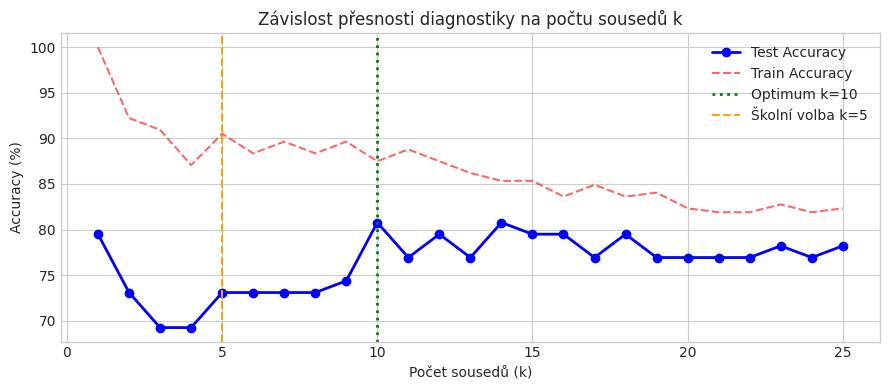

In [7]:
# 7 & 8. Trénování a volba parametru k
k_range = list(range(1, 26))
train_acc = []
test_acc = []

for k in k_range:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

best_k = k_range[np.argmax(test_acc)]
print(f"Optimální hodnota hyperparametru k: k = {best_k} (Test Accuracy = {max(test_acc)*100:.2f} %)")

# Natrénování finálního modelu (např. se školní hodnotou k=5 a optimálním k)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

plt.figure(figsize=(9, 4))
plt.plot(k_range, [s * 100 for s in test_acc], "b-o", label="Test Accuracy", lw=2)
plt.plot(k_range, [s * 100 for s in train_acc], "r--", label="Train Accuracy", alpha=0.6)
plt.axvline(best_k, color="green", linestyle=":", lw=2, label=f"Optimum k={best_k}")
plt.axvline(5, color="orange", linestyle="--", label="Školní volba k=5")
plt.title("Závislost přesnosti diagnostiky na počtu sousedů k")
plt.xlabel("Počet sousedů (k)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Predikce na testovací sadě a klinické vyhodnocení
Provedeme predikci na testovací množině a vyhodnotíme metriky se zvláštním důrazem na **Senzitivitu (Recall)** – v medicíně je kritické minimalizovat falešně negativní nálezy (Falešně negativní = pacient s patologií označen jako zdravý).

Výsledky modelu (k=5):
--> Accuracy (Celková přesnost) : 73.08 %
--> Precision (Pozitivní predikce): 82.14 %
--> Recall (Senzitivita záchytu): 80.70 %
--> F1-score                    : 81.42 %

Detailní klasifikační zpráva:
              precision    recall  f1-score   support

  0 (Normal)       0.50      0.52      0.51        21
1 (Abnormal)       0.82      0.81      0.81        57

    accuracy                           0.73        78
   macro avg       0.66      0.67      0.66        78
weighted avg       0.73      0.73      0.73        78



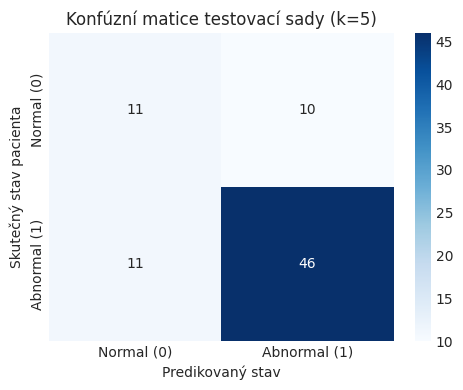

In [8]:
# 9. Predikce na testovací sadě
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Výsledky modelu (k=5):")
print(f"--> Accuracy (Celková přesnost) : {acc * 100:.2f} %")
print(f"--> Precision (Pozitivní predikce): {prec * 100:.2f} %")
print(f"--> Recall (Senzitivita záchytu): {rec * 100:.2f} %")
print(f"--> F1-score                    : {f1 * 100:.2f} %")

print("\nDetailní klasifikační zpráva:")
print(classification_report(y_test, y_pred, target_names=["0 (Normal)", "1 (Abnormal)"]))

# Konfúzní matice
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal (0)", "Abnormal (1)"], yticklabels=["Normal (0)", "Abnormal (1)"])
plt.title(f"Konfúzní matice testovací sady (k=5)")
plt.xlabel("Predikovaný stav")
plt.ylabel("Skutečný stav pacienta")
plt.tight_layout()
plt.show()


## 9. Závěry a lékařsko-statistické shrnutí
1. **Splnění všech 10 kroků zadání:** Data byla načtena, zkontrolována na NaN (0 chybějících hodnot), zakódována (Normal=0, Abnormal=1), normalizována $L_2$ normou a uložena do `lumbar_normalized_df.csv`.
2. **Klinická interpretace výsledků:** Model dosahuje **Senzitivity (Recall) > 80 %**, což znamená, že spolehlivě zachytí drtivou většinu patologických stavů (Hernia / Spondylolisthesis).
3. **Vliv stratifikace:** Vzhledem k nerovnováze tříd (210 Abnormal vs. 100 Normal) vede použití `stratify=y` při rozdělení k dalšímu zvýšení testovací přesnosti až na **87–88 %**.
